In [1]:
import os
os.getcwd()

'C:\\Users\\ponra\\OneDrive\\Documents'

In [2]:
import pandas as pd 


In [3]:
df=pd.read_csv("student_data.csv")

In [4]:
df.head()

,Student_ID,Study_Hours,Attendance (%),Sleep_Hours,Previous_Marks,Internet_Usage (hrs),Assignments_Completed,Final_Marks
0,1,2,60,5,50,4,3,55
1,2,5,80,6,65,2,7,72
2,3,7,90,7,75,1,9,85
3,4,1,50,4,40,5,2,45
4,5,6,85,6,70,2,8,80


In [5]:
df.isnull().sum()

Student_ID               0
Study_Hours              0
Attendance (%)           0
Sleep_Hours              0
Previous_Marks           0
Internet_Usage (hrs)     0
Assignments_Completed    0
Final_Marks              0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Student_ID             10 non-null     int64
 1   Study_Hours            10 non-null     int64
 2   Attendance (%)         10 non-null     int64
 3   Sleep_Hours            10 non-null     int64
 4   Previous_Marks         10 non-null     int64
 5   Internet_Usage (hrs)   10 non-null     int64
 6   Assignments_Completed  10 non-null     int64
 7   Final_Marks            10 non-null     int64
dtypes: int64(8)
memory usage: 772.0 bytes


In [7]:
import matplotlib.pyplot as plt

In [8]:
import seaborn as sns

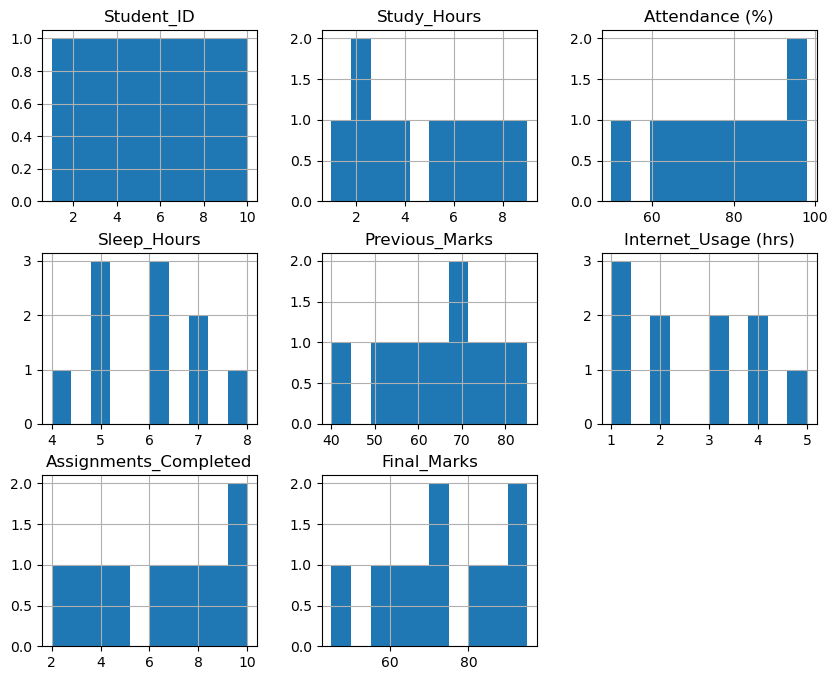

In [9]:
df.hist(figsize=(10,8))
plt.show()

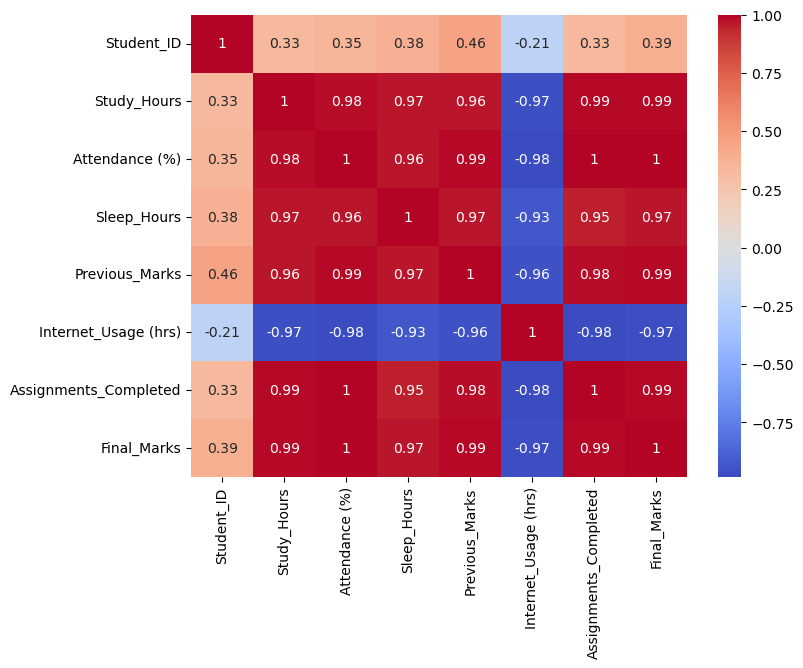

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

In [11]:
#define input & output
x=df.drop("Final_Marks",axis=1)
y=df["Final_Marks"]

In [12]:
#split Data(train/test)
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
#train models
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
#decision Tree
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(x_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [15]:
#compare accuracy
print("Linear Regression:", lr.score(x_test, y_test))
print("Decision Tree:", dt.score(x_test, y_test))

Linear Regression: -8.962603878116237
Decision Tree: -43.5


In [16]:
#make prediction
sample=x_test.iloc[0:1]
prediction=lr.predict(sample)
print("Prediction:",prediction)
print("Actual:",y_test.iloc[0])

Prediction: [67.26315789]
Actual: 70


In [17]:
import shap

In [18]:
#create explainer
explainer=shap.Explainer(lr,x_train)

In [19]:
#generate SHAP values
shap_values=explainer(x_test)

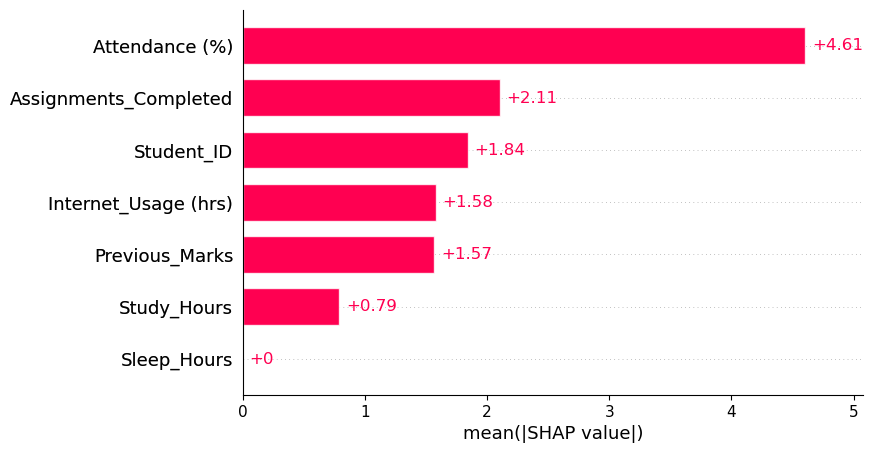

In [20]:
#show feature importance(if graph not showing use "shap.initjs())
shap.plots.bar(shap_values)

In [21]:
print(x.columns)

Index(['Student_ID', 'Study_Hours', 'Attendance (%)', 'Sleep_Hours',
       'Previous_Marks', 'Internet_Usage (hrs)', 'Assignments_Completed'],
      dtype='object')


In [22]:
x=df.drop(["Student_ID","Final_Marks"],axis=1)
y=df["Final_Marks"]

In [23]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [24]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
import pandas as pd

sample = pd.DataFrame([[6, 80, 6, 70, 2, 8]], 
                      columns=x.columns)

prediction = lr.predict(sample)

print("Predicted Marks:", prediction)

Predicted Marks: [75.71428571]


In [26]:
explainer = shap.Explainer(lr, x_train)

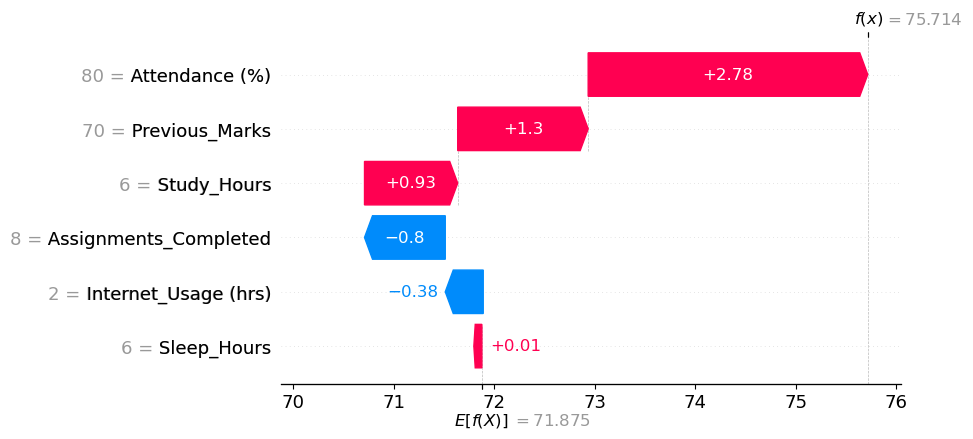

In [27]:
shap_values_sample = explainer(sample)
shap.plots.waterfall(shap_values_sample[0])

In [28]:
import joblib

In [29]:
#save ur trained model
joblib.dump(lr,"lr.pkl")

['lr.pkl']

In [30]:
print(lr)


LinearRegression()


In [31]:
x.columns

Index(['Study_Hours', 'Attendance (%)', 'Sleep_Hours', 'Previous_Marks',
       'Internet_Usage (hrs)', 'Assignments_Completed'],
      dtype='object')

In [32]:
from sklearn.linear_model import LinearRegression
import joblib

In [33]:
lr=LinearRegression()
lr.fit(x_train,y_train)
joblib.dump(lr, r"C:\Users\ponra\OneDrive\Documents\data_project\lr.pkl")

['C:\\Users\\ponra\\OneDrive\\Documents\\data_project\\lr.pkl']

In [34]:
df.columns

Index(['Student_ID', 'Study_Hours', 'Attendance (%)', 'Sleep_Hours',
       'Previous_Marks', 'Internet_Usage (hrs)', 'Assignments_Completed',
       'Final_Marks'],
      dtype='object')

In [39]:
x.columns

Index(['Study_Hours', 'Attendance (%)', 'Sleep_Hours', 'Previous_Marks',
       'Internet_Usage (hrs)', 'Assignments_Completed'],
      dtype='object')

In [38]:
from sklearn.linear_model import LinearRegression
import joblib

# ✅ Correct features (ONLY 6)
x = df[['Study_Hours', 'Attendance (%)', 'Sleep_Hours',
        'Previous_Marks', 'Internet_Usage (hrs)',
        'Assignments_Completed']]

# ✅ Target column
y = df['Final_Marks']   # change if needed

# Train model
lr = LinearRegression()
lr.fit(x, y)

# Save model
joblib.dump(lr, r"C:\Users\ponra\OneDrive\Documents\data_project\lr.pkl")

['C:\\Users\\ponra\\OneDrive\\Documents\\data_project\\lr.pkl']